In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import re, math, textwrap
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
import seaborn as sns
import re
import warnings
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
warnings.filterwarnings("ignore")

# Optional: nice dataframe display in notebooks (falls back to print)
try:
    from IPython.display import display  # type: ignore
    def display_df(title, x):
        print(title)
        display(x)
except Exception:
    def display_df(title, x):
        print(title)
        print(x)


# Set the input path ONCE (edit this one line only)
OPEN_FIELD_XLSX_PATH = Path("/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/csv_files/open_field.xlsx")
OPEN_FIELD_DIR = OPEN_FIELD_XLSX_PATH.parent
OPEN_FIELD_OUTDIR = OPEN_FIELD_DIR.parent / "OpenFieldAnalysis"
# (or, if you want it INSIDE the same folder as the excel:)
# OPEN_FIELD_OUTDIR = OPEN_FIELD_DIR / "OpenFieldAnalysis"

OPEN_FIELD_OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", OPEN_FIELD_OUTDIR)

df_open_field = pd.read_excel(OPEN_FIELD_XLSX_PATH) #select all cells in all trials

# check if parket file exists and is up to date, otherwise save to parquet for faster loading next time
PARQUET_PATH = os.path.join(OPEN_FIELD_OUTDIR, "open_field.parquet")
df_open_field.to_parquet(PARQUET_PATH, index=False)
df_open_field = pd.read_parquet(PARQUET_PATH)


# Keep only openfieldb trials
df_open_field = df_open_field.loc[
    df_open_field["trial_type"].astype(str).str.contains("openfieldb", na=False)
].copy()

print("________________________________________________________________")
print(df_open_field["trial_type"].value_counts(dropna=False).head(10))
print("________________________________________________________________")
print("Dataframe:", df_open_field.shape, df_open_field.columns.tolist(), df_open_field.head())


Saving outputs to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis
________________________________________________________________
trial_type
['openfieldb']    1130
Name: count, dtype: int64
________________________________________________________________
Dataframe: (1130, 30) ['filename', 'channel', 'cluster', 'trial_type', 'peak_rate', 'mean_firing_rate', 'num_spikes', 'spike_width', 'AHP_decay', 'theta_modulation', 'field_size', 'phase_mean', 'phase_variance', 'odd_even_stability', 'half_split_stability', 'overdispersion', 'spatial_info', 'coherence', 'phase_locking_vector_length', 'phase_locking_z_stat', 'phase_locking_pval', 'mouse_name', 'Genotype', 'Cell type', 'Experimenter', 'Age_weeks', 'head_dir_mean_resultant_length', 'head_dir_mean_resultant_angle', 'contamination_Q', 'contamination_R']                                             filename  channel  cluster  \
0  /home/robin/Documents/Science/SWC/jok_loukia_r...  

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

def _safe_filename(s: str) -> str:
    import re
    s = str(s).strip()
    s = re.sub(r"[^\w\-.]+", "_", s)
    return s[:180]

def lmer_fit_and_diagnostics_png(
    df: pd.DataFrame,
    metric: str,
    outdir: str | Path,
    genotype_col: str = "Genotype",
    celltype_col: str = "Cell type",
    animal_col: str = "mouse_name",
    reml: bool = False,
):
    # --- prep in python ---
    outdir = Path(outdir)
    diag_dir = outdir / "lmer_residual_diagnostics"
    diag_dir.mkdir(parents=True, exist_ok=True)

    d = df[[metric, genotype_col, celltype_col, animal_col]].dropna().copy()
    d["y_tmp"] = pd.to_numeric(d[metric], errors="coerce")
    d = d.dropna(subset=["y_tmp"])

    # rename to safe R names
    d = d.rename(columns={
        genotype_col: "Genotype",
        celltype_col: "Cell_type",
        animal_col: "mouse_name",
    })

    png_path = diag_dir / f"diagnostics_{_safe_filename(metric)}.png"

    # --- run R via rpy2 ---
    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.conversion import localconverter

    ro.r("suppressPackageStartupMessages(library(lmerTest))")
    ro.r("suppressPackageStartupMessages(library(performance))")

    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(d)

    ro.globalenv["dat"] = r_df
    ro.globalenv["DIAG_PNG"] = str(png_path)
    ro.globalenv["REML_FLAG"] = bool(reml)

    r_code = r"""
    dat2 <- dat
    dat2$Genotype   <- factor(as.character(dat2$Genotype))
    dat2$Cell_type  <- factor(as.character(dat2$Cell_type))
    dat2$mouse_name <- factor(as.character(dat2$mouse_name))
    dat2 <- droplevels(dat2)

    fit <- lmer(y_tmp ~ Genotype * Cell_type + (1|mouse_name), data=dat2, REML=REML_FLAG)

    # Optional numeric check (prints to console)
    hetero <- tryCatch(performance::check_heteroscedasticity(fit), error=function(e) e)

    # --- Residual diagnostics PNG (Q-Q + Residuals vs Fitted) ---
    png(filename = DIAG_PNG, width = 1400, height = 650, res = 150)
    par(mfrow = c(1,2))

    res <- residuals(fit)
    fv  <- fitted(fit)

    qqnorm(res, main="Residuals Q-Q")
    qqline(res, col="red", lwd=2)

    plot(fv, res, xlab="Fitted values", ylab="Residuals",
         main="Residuals vs Fitted", pch=16, cex=0.6)
    abline(h=0, col="red", lwd=2)

    dev.off()
    par(mfrow = c(1,1))

    list(
      png = DIAG_PNG,
      hetero = hetero
    )
    """

    out = ro.r(r_code)
    png_out = str(out.rx2("png")[0])

    # hetero object is an R object; printing it in python is usually enough
    hetero_obj = out.rx2("hetero")
    print("Saved diagnostics PNG:", png_out)
    print("Heteroskedasticity check (R/performance):")
    print(hetero_obj)

    return png_out

# Example usage (uses your existing OPEN_FIELD_OUTDIR and df_transform):
#TODO: make sure df_transform is defined AND PERHAPS MOVE IT AFTER THE NEXT CELL WHERE YOU DEFINE df_transform, so that it runs after the transformation is done.
png_path = lmer_fit_and_diagnostics_png(df_transform, metric="spike_width", outdir=OPEN_FIELD_OUTDIR)

Saved diagnostics PNG: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/lmer_residual_diagnostics/diagnostics_spike_width.png
Heteroskedasticity check (R/performance):



In [ ]:
"""
Now we have a dataframe with all the openfieldb trials, and we want to add transformed columns for better visualization 
and stats later on.
The code below applies log, log1p, logit, and Yeo-Johnson transforms to selected columns, 
creating new columns with suffixes like _log, _log1p, _logit, and _yj.
You can edit the lists of columns to transform according to your needs. 
The helper functions handle edge
cases like zeros or values outside the (0,1) range for log and logit transforms.
"""

import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer

path = "/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/open_field.parquet"
out_path = path.replace(".parquet", "_with_transforms.parquet")

df_transform = pd.read_parquet(path, engine="pyarrow")

# --- helpers ---
def safe_log(x, eps=1e-12):
    x = pd.to_numeric(x, errors="coerce")
    return np.log(x.clip(lower=eps))

def safe_log1p(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.log1p(x.clip(lower=0))

def logit01(x, eps=1e-6):
    x = pd.to_numeric(x, errors="coerce")
    p = x.clip(eps, 1 - eps)
    return np.log(p / (1 - p))

def yeo_johnson(x):
    x = pd.to_numeric(x, errors="coerce")
    mask = x.notna()
    out = pd.Series(np.nan, index=x.index, dtype="float64")
    if mask.sum() >= 2:
        pt = PowerTransformer(method="yeo-johnson", standardize=False)
        out.loc[mask] = pt.fit_transform(x.loc[mask].to_numpy().reshape(-1,1)).ravel()
    return out

# --- choose transforms (edit these lists to your needs) ---
log_cols = ["peak_rate", "mean_firing_rate", "overdispersion",
            "spatial_info", "phase_locking_z_stat", "head_dir_mean_resultant_length", 
            ]  # positive values, but can be zero or very small

log1p_cols = ["num_spikes"]  # counts with possible zeros

logit_cols = ["phase_variance","phase_locking_vector", "contamination_R" ]  # bounded 0..1

pval_cols = ["phase_locking_p_value"]  # if you insist keeping it: -log10(p)

yj_cols = ["theta_modulation", "odd_even_stability"]  # only if a column can be negative or crosses 0 (e.g., if your theta_modulation sometimes does)

no_transform_cols = ["num_spikes", "AHP_decay", "field_size", "phase_mean", 
                     "half_split_stability", "coherence"
                     "head_dir_mean_resultant_angle", "contamination_Q", 
                     ]  # if you want to keep the original without transform, but it doesn't need one

# --- apply ---
for c in log_cols:
    if c in df_transform.columns:
        df_transform[c + "_log"] = safe_log(df_transform[c])

for c in log1p_cols:
    if c in df_transform.columns:
        df_transform[c + "_log1p"] = safe_log1p(df_transform[c])

for c in logit_cols:
    if c in df_transform.columns:
        df_transform[c + "_logit"] = logit01(df_transform[c])

for c in pval_cols:
    if c in df_transform.columns:
        p = pd.to_numeric(df_transform[c], errors="coerce").clip(1e-300, 1.0)
        df_transform[c + "_mlog10"] = -np.log10(p)

for c in yj_cols:
    if c in df_transform.columns:
        df_transform[c + "_yj"] = yeo_johnson(df_transform[c])

# Optional: make sure categoricals don't cause parquet quirks
# df_transform = df_transform.copy()
# for c in df_transform.select_dtypes(["category"]).columns:
#     df_transform[c] = df_transform[c].astype("string")

df_transform.to_parquet(out_path, index=False, engine="pyarrow")
print("Wrote:", out_path)
#save as csv if you want to open in excel, but parquet is better for pandas
df_transform.to_csv(out_path.replace(".parquet", ".csv"), index=False)


Wrote: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/open_field_with_transforms.parquet


In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer

yj_cols = ["theta_modulation", "odd_even_stability"]

def add_yeo_johnson_columns(df: pd.DataFrame, cols, suffix="_yj", standardize=False):
    """
    Adds Yeo–Johnson transformed versions of cols to df as <col><suffix>.
    Returns (df_out, lambda_table_df)
    """
    df_out = df.copy()
    lambda_rows = []

    for col in cols:
        if col not in df_out.columns:
            print(f"Skipping {col}: not in dataframe")
            continue

        s = pd.to_numeric(df_out[col], errors="coerce")
        mask = s.notna()

        if mask.sum() < 3:
            print(f"Skipping {col}: not enough non-missing values (n={mask.sum()})")
            df_out[col + suffix] = np.nan
            continue

        pt = PowerTransformer(method="yeo-johnson", standardize=standardize)
        yj = pt.fit_transform(s.loc[mask].to_numpy().reshape(-1, 1)).ravel()

        df_out[col + suffix] = np.nan
        df_out.loc[mask, col + suffix] = yj

        lambda_rows.append({
            "column": col,
            "n_used": int(mask.sum()),
            "lambda": float(pt.lambdas_[0]),
            "standardize": bool(standardize),
            "new_column": col + suffix
        })

    lambda_df = pd.DataFrame(lambda_rows)
    return df_out, lambda_df

df_open_field, yj_lambda_table = add_yeo_johnson_columns(
    df_open_field, yj_cols, suffix="_yj", standardize=False
)

display(yj_lambda_table)
save_path = os.path.join(OPEN_FIELD_OUTDIR, "yeo_johnson_lambda_table.csv")
yj_lambda_table.to_csv(save_path, index=False)
print("Saved Yeo-Johnson lambda table to:", save_path)



,column,n_used,lambda,standardize,new_column
0,theta_modulation,1130,-3.740457,False,theta_modulation_yj
1,odd_even_stability,1130,2.032686,False,odd_even_stability_yj


Saved Yeo-Johnson lambda table to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/yeo_johnson_lambda_table.csv


In [3]:
"""
Stats functions and plotting utilities for Open field analysis
"""

import itertools
import matplotlib.patches as mpatches

def _find_col(df, names):
    def norm(s):
        return re.sub(r"[\s_]+", "", str(s)).lower()
    norm_map = {norm(c): c for c in df.columns}
    for n in names:
        key = norm(n)
        if key in norm_map:
            return norm_map[key]
    raise KeyError(f"Could not find any of {names}. Available columns: {list(df.columns)}")

def _sig_stars(p):
    if p is None or not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

def _format_p(p):
    if p is None or not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def _build_order(levels, preferred_tokens):
    levels = [lv for lv in levels if pd.notna(lv)]
    used = set()
    out = []

    def norm(x): 
        return str(x).strip().lower()

    for tok in preferred_tokens:
        tok_n = tok.lower()
        match = None
        for lv in levels:
            lv_n = norm(lv)
            if lv_n == tok_n or tok_n in lv_n:
                match = lv
                break
        if match is not None and match not in used:
            out.append(match)
            used.add(match)

    for lv in levels:
        if lv not in used:
            out.append(lv)
    return out

def _tukey_pairs(df_ct_stats: pd.DataFrame, metric: str, genotype_col: str, present_genos: list):
    work = df_ct_stats[[metric, genotype_col]].dropna().copy()
    work[metric] = pd.to_numeric(work[metric], errors="coerce")
    work = work.dropna(subset=[metric])

    counts = work.groupby(genotype_col)[metric].size()
    valid_genos = counts[counts >= 2].index.tolist()
    work = work[work[genotype_col].isin(valid_genos)]
    if work[genotype_col].nunique() < 2:
        return []

    tuk = pairwise_tukeyhsd(
        endog=work[metric].to_numpy(),
        groups=work[genotype_col].astype(str).to_numpy(),
        alpha=0.05
    )
    tuk_df = pd.DataFrame(tuk._results_table.data[1:], columns=tuk._results_table.data[0])

    geno_lookup = {str(g): g for g in present_genos}
    out = []
    for _, r in tuk_df.iterrows():
        g1s, g2s = str(r["group1"]), str(r["group2"])
        if g1s in geno_lookup and g2s in geno_lookup:
            out.append(((geno_lookup[g1s], geno_lookup[g2s]), float(r["p-adj"])))
    return out

# BRACKETS # Utility function to draw significance brackets between two x positions at a given y level with a label (e.g. p-value)
def _draw_bracket(ax, x1, x2, y, h, text, fontsize=8):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, c="black", zorder=8)
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=fontsize, zorder=9)


# This is a utility function to drop boxplot fliers (for cleaner visualization) while keeping the underlying data points for stats tests and median overlay.
def _drop_boxplot_fliers_points_only(df: pd.DataFrame, metric: str, group_cols: list[str]) -> pd.DataFrame:
    g = df.groupby(group_cols)[metric]
    q1 = g.quantile(0.25)
    q3 = g.quantile(0.75)
    iqr = q3 - q1
    lo = (q1 - 1.5 * iqr).rename("lo")
    hi = (q3 + 1.5 * iqr).rename("hi")

    bounds = pd.concat([lo, hi], axis=1).reset_index()
    tmp = df.merge(bounds, on=group_cols, how="left")
    tmp = tmp[tmp[metric].between(tmp["lo"], tmp["hi"], inclusive="both")]
    return tmp.drop(columns=["lo", "hi"])

# Utility to make a string safe for filenames (removes/replace special characters, truncates to reasonable length)
def _safe_filename(s: str) -> str:
    s = str(s).strip()
    s = re.sub(r"[^\w\-.]+", "_", s)  # keep letters/numbers/_/./-
    return s[:180]

# Utility to ensure a path is a pathlib.Path object
def _as_path(p):
    return p if isinstance(p, Path) else Path(str(p))

# Main analysis function: runs 2-way ANOVA and saves boxplots by Genotype and Cell type
def analyze_open_field_by_celltype_and_genotype(
    df_open_field: pd.DataFrame,
    outdir: str,
    celltype_col: str | None = None,
    genotype_col: str | None = None,
    exclude_numeric_cols: list[str] | None = None,
    min_n: int = 10,
    save_png: bool = True,
    png_dpi: int = 300,
    png_figsize: tuple[float, float] | None = (6.5, 3.6),  # quarter-slide for 16:9
):
      
    if celltype_col is None:
        celltype_col = _find_col(df_open_field, ["Cell Type", "Cell type", "cell_type", "celltype"])
    if genotype_col is None:
        genotype_col = _find_col(
            df_open_field,
            ["Genotype", "Phenotype", "genotype", "geno", "genotype_group", "Genotype group"],
        )

    print("Using CellType_COL =", celltype_col)
    print("Using Genotype_COL =", genotype_col)

    numeric_cols = df_open_field.select_dtypes(include=[np.number]).columns.tolist()
    exclude = set(exclude_numeric_cols or ["tetrode", "channel", "cluster", "mouse_name"])
    cols_to_use = [c for c in numeric_cols if c not in exclude]

    # ---------- 1) 2-way ANOVA: Genotype x Cell type ----------
    anova_rows = []
    term_gt = f'C(Q("{genotype_col}"))'
    term_ct = f'C(Q("{celltype_col}"))'
    term_int = f"{term_gt}:{term_ct}"

    for metric in cols_to_use:
        test_data = df_open_field[[metric, genotype_col, celltype_col]].dropna()
        if len(test_data) < min_n:
            continue
        if test_data[genotype_col].nunique() < 2 or test_data[celltype_col].nunique() < 2:
            continue

        try:
            formula = f'Q("{metric}") ~ {term_gt} * {term_ct}'
            model = ols(formula, data=test_data).fit()
            aov = anova_lm(model, typ=3)  # Type III ANOVA

            p_gt  = float(aov.loc[term_gt,  "PR(>F)"]) if term_gt  in aov.index else np.nan
            p_ct  = float(aov.loc[term_ct,  "PR(>F)"]) if term_ct  in aov.index else np.nan
            p_int = float(aov.loc[term_int, "PR(>F)"]) if term_int in aov.index else np.nan

            f_gt  = float(aov.loc[term_gt,  "F"]) if term_gt  in aov.index and "F" in aov.columns else np.nan
            f_ct  = float(aov.loc[term_ct,  "F"]) if term_ct  in aov.index and "F" in aov.columns else np.nan
            f_int = float(aov.loc[term_int, "F"]) if term_int in aov.index and "F" in aov.columns else np.nan

            anova_rows.append({
                "column": metric,
                "n_observations": int(len(test_data)),
                "n_genotypes": int(test_data[genotype_col].nunique()),
                "n_cell_types": int(test_data[celltype_col].nunique()),
                "F_Genotype": f_gt,
                "F_CellType": f_ct,
                "F_Interaction": f_int,
                "p_Genotype": p_gt,
                "p_CellType": p_ct,
                "p_Interaction": p_int,
                "sig_Genotype": _sig_stars(p_gt),
                "sig_CellType": _sig_stars(p_ct),
                "sig_Interaction": _sig_stars(p_int),
            })
        except Exception as e:
            print(f"Could not run ANOVA for {metric}: {e}")

    df_anova = pd.DataFrame(anova_rows).sort_values("p_Genotype", na_position="last")
    display_df("2-way ANOVA: Genotype x Cell type", df_anova)

    anova_save_path = os.path.join(outdir, "open_field_2way_anova_genotype_celltype.csv")
    df_anova.to_csv(anova_save_path, index=False)
    print(f"Saved ANOVA table to: {anova_save_path}")

    aov_lookup = df_anova.set_index("column").to_dict(orient="index")

    # ---------- 2) Boxplots PDF: metric by Cell type (hue=Genotype) ----------
    pdf_path = os.path.join(outdir, "open_field_boxplots_by_genotype_and_celltype.pdf")
    outdir_path = _as_path(outdir)
    
    png_dir = outdir_path / "png"
    if save_png:
        png_dir.mkdir(parents=True, exist_ok=True)

    with PdfPages(pdf_path) as pdf:
        fig = plt.figure(figsize=(11.69, 8.27)) # A4 landscape
        gt_levels = sorted(df_open_field[genotype_col].dropna().unique().tolist())
        ct_levels = sorted(df_open_field[celltype_col].dropna().unique().tolist())
        txt = (
            "Open field dataset - Boxplots by Genotype and Cell type\n"
            f"Genotypes: {', '.join(map(str, gt_levels))}\n"
            f"Cell types: {', '.join(map(str, ct_levels))}\n"
            "Black diamonds = medians (value printed)\n"
            "Brackets = pairwise genotype post-hoc p-values within each cell type (Tukey HSD-adjusted)\n"
            "Outliers removed from boxplots for visualization, but all points used for stats and median calculation"
        )
        
        fig.text(0.05, 0.9, txt, fontsize=20, va="top") 
        plt.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        hue_order = _build_order(gt_levels, ["WT", "NLGF"])
        x_order = _build_order(ct_levels, ["pyramidal", "interneurons"])

        box_width = 0.32
        point_jitter = 0.30
        point_alpha = 0.4
        point_size = 2.0


        for metric in cols_to_use:
            plot_data = df_open_field[[metric, genotype_col, celltype_col]].dropna()
            if len(plot_data) == 0:
                continue
            if plot_data[celltype_col].nunique() < 2:
                continue
            if plot_data[genotype_col].nunique() < 2:
                continue

            fig = plt.figure(figsize=(png_figsize if (save_png and png_figsize) else (11.69, 8.27)))
            ax = fig.add_subplot(111)

            # --- palette: make WT lighter blue ---
            base = sns.color_palette("tab10", n_colors=len(hue_order))
            palette = dict(zip(hue_order, base))
            
            for g in hue_order:
                if "wt" in str(g).strip().lower():
                    palette[g] = sns.color_palette("Blues", 6)[2]  # lighter blue
                if "nlgf" in str(g).strip().lower():
                    palette[g] = sns.color_palette("Oranges", 6)[2]  # lighter orange

            n_hue = max(1, len(hue_order))
            j = 0.8 * (box_width / (2 * n_hue))   # e.g. ~0.09 when n_hue=2


            sns.boxplot(
                data=plot_data,
                x=celltype_col,
                y=metric,
                hue=genotype_col,
                order=x_order,
                hue_order=hue_order,
                palette=palette,
                showfliers=False,
                # width=box_width,
                linewidth=0.8,
                ax=ax,
            )

            plot_points = _drop_boxplot_fliers_points_only(plot_data, metric, [celltype_col, genotype_col])
            if plot_points.empty:
                plot_points = plot_data  # fallback: avoid seaborn error if everything got filtered
            
            
            sns.stripplot(
                data=plot_points,
                x=celltype_col,
                y=metric,
                hue=genotype_col,
                order=x_order,
                hue_order=hue_order,
                palette=palette,
                dodge=True,
                jitter=point_jitter,
                size=point_size,
                alpha=point_alpha,
                linewidth=0.25,
                ax=ax,
                legend=False,  # we'll add a custom legend later (to avoid duplicate entries from boxplot and stripplot
            )

            title_fs = 12
            fstats_fs = 7
            label_fs = 9
            tick_fs = 8
            legend_fs = 8
            legend_title_fs = 9
            
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(
                by_label.values(),
                by_label.keys(),
                title=genotype_col,
                title_fontsize=legend_title_fs,
                fontsize=legend_fs,
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                borderaxespad=0,
            )

            # ---- Title + F-stats (2nd line) ----
            row = aov_lookup.get(metric, {})
            f_gt = row.get("F_Genotype", np.nan)
            f_ct = row.get("F_CellType", np.nan)
            f_int = row.get("F_Interaction", np.nan)

            p_gt  = row.get("p_Genotype", np.nan)
            p_ct  = row.get("p_CellType", np.nan)
            p_int = row.get("p_Interaction", np.nan)
            
            fline = (
                f"F_Genotype={f_gt:.3f} (p={_format_p(p_gt)})    "
                f"F_CellType={f_ct:.3f} (p={_format_p(p_ct)})    "
                f"F_Interaction={f_int:.3f} (p={_format_p(p_int)})"
            )
        
            
            # ax.set_title(f"{metric}\n{fline}")
            pretty = str(metric).replace("_", " ").title()
            ax.set_title(pretty, fontsize=title_fs, fontweight="bold", pad=14)

            # ax.set_title(metric, fontsize=title_fs, fontweight="bold", pad=14)
            
            ax.text(
                0.5, 1.01, fline,
                transform=ax.transAxes,
                ha="center", va="bottom",
                fontsize=fstats_fs,
                fontweight="bold",
                # fontstyle="italic",
                color = "dimgray",
            )
            
            ax.set_xlabel(celltype_col, fontsize=label_fs, fontweight="bold")
            ax.set_ylabel(pretty, fontsize=label_fs, fontweight="bold")
            ax.tick_params(axis="both", labelsize=tick_fs)
            ax.tick_params(axis="x")  # rotation = 30 is usually enough for small plots; here I dind't use it
            
            # ---- Median overlay (diamond + value) ----
            med = (
                plot_data
                .groupby([celltype_col, genotype_col], dropna=False)[metric]
                .median()
                .reset_index(name="median")
            )

            m = max(1, len(hue_order))
            box_width = 0.8
            y0, y1 = ax.get_ylim()
            ypad = 0.05 * (y1 - y0)
            label_pad = 0.01 * (y1 - y0)

            for i, ct in enumerate(x_order):
                for j, gt in enumerate(hue_order):
                    sub = med[(med[celltype_col] == ct) & (med[genotype_col] == gt)]
                    if sub.empty:
                        continue
                    med_val = float(sub["median"].iloc[0])
                    offset = (j - (m - 1) / 2) * (box_width / m)
                    x_pos = i + offset
                    ax.scatter([x_pos], [med_val], color="black", s=5, marker="D", zorder=6)
                    ax.text(x_pos, med_val + label_pad, f"{med_val:.3g}", ha="center", va="bottom", fontsize=7, zorder=7, fontweight="normal", fontstyle="italic")


            # ---- Pairwise genotype p-values within each cell type (brackets) ----
            geno_to_index = {g: idx for idx, g in enumerate(hue_order)}
            ct_to_index = {ct: idx for idx, ct in enumerate(x_order)}
            
            # Use the CURRENT limits from what is actually drawn (boxplot + stripplot)
            y0, y1 = ax.get_ylim()
            yr_vis = y1 - y0
            ypad = 0.05 * yr_vis
            h = 0.01 * yr_vis
            
            # ---- Pairwise genotype post-hoc within each cell type (Tukey HSD) ----
            geno_to_index = {g: idx for idx, g in enumerate(hue_order)}
            ct_to_index = {ct: idx for idx, ct in enumerate(x_order)}

            # Use the CURRENT limits from what is actually drawn (boxplot + stripplot)
            y0, y1 = ax.get_ylim()
            yr_vis = y1 - y0
            ypad = 0.05 * yr_vis
            h = 0.01 * yr_vis

            # -------- Pass 1: compute stats (plot_data) + decide bracket baselines (plot_points)
            ct_results = {}   # ct -> list of ((g1,g2), p_adj_from_tukey)
            ct_ybase = {}     # ct -> visible max
            y_needed_top = y1

            for ct in x_order:
                df_ct_stats = plot_data[plot_data[celltype_col] == ct]
                if df_ct_stats.empty:
                    continue

                df_ct_vis = plot_points[plot_points[celltype_col] == ct]
                if df_ct_vis.empty:
                    # nothing visible for this cell type -> don't draw brackets
                    continue

                y_base = float(df_ct_vis[metric].max())
                ct_ybase[ct] = y_base

                present_genos = [g for g in hue_order if g in set(df_ct_stats[genotype_col].unique())]
                if len(present_genos) < 2:
                    continue

                pairs_with_p = _tukey_pairs(df_ct_stats, metric, genotype_col, present_genos)
                if not pairs_with_p:
                    continue

                ct_results[ct] = pairs_with_p

                # how high we may need to go for this ct (stacking)
                n = len(ct_results[ct])
                top_for_ct = y_base + ypad + (n - 1) * ypad + h + ypad
                y_needed_top = max(y_needed_top, top_for_ct)

            # Set ylim once, high enough for all brackets
            ax.set_ylim(y0, y_needed_top)

            # -------- Pass 2: draw brackets using visible-based y positions
            stack_y = {ct: ct_ybase[ct] + ypad for ct in ct_results.keys()}

            for ct, results in ct_results.items():
                i = ct_to_index[ct]
                for (g1, g2), padj in results:
                    j1 = geno_to_index[g1]
                    j2 = geno_to_index[g2]
                    off1 = (j1 - (m - 1) / 2) * (box_width / m)
                    off2 = (j2 - (m - 1) / 2) * (box_width / m)
                    x_left = i + off1
                    x_right = i + off2
                    if x_left > x_right:
                        x_left, x_right = x_right, x_left

                    y = stack_y[ct]
                    label = f"p={_format_p(padj)} ({_sig_stars(padj)})"
                    _draw_bracket(ax, x_left, x_right, y, h, label, fontsize=8)
                    stack_y[ct] = y + ypad

            fig.tight_layout()
            if save_png:
                png_name = f"{_safe_filename(metric)}__by_celltype_hue_genotype.png"
                png_path = png_dir / png_name
                fig.savefig(png_path, dpi=png_dpi, bbox_inches="tight")
            pdf.savefig(fig)
            plt.close(fig)

    print(f"Saved boxplots PDF to: {pdf_path}")
    return df_anova, anova_save_path, pdf_path



In [4]:
# Run the ANOVA and boxplot analysis for all numeric columns by Genotype and Cell type 
df_anova_genotype_celltype, anova_csv, boxplot_pdf = analyze_open_field_by_celltype_and_genotype(
    df_open_field=df_transform,
    outdir=OPEN_FIELD_OUTDIR,
)

Using CellType_COL = Cell type
Using Genotype_COL = Genotype
2-way ANOVA: Genotype x Cell type


,column,n_observations,n_genotypes,n_cell_types,F_Genotype,F_CellType,F_Interaction,p_Genotype,p_CellType,p_Interaction,sig_Genotype,sig_CellType,sig_Interaction
17,Age_weeks,2214,2,2,75.850836,3.083023,0.223957,5.878175e-18,7.925185e-02,6.360881e-01,***,ns,ns
9,odd_even_stability,2214,2,2,53.969150,60.819256,17.588833,2.850453e-13,9.563728e-15,2.850126e-05,***,***,***
32,odd_even_stability_yj,2214,2,2,52.326703,56.937530,22.242516,6.449309e-13,6.533709e-14,2.552842e-06,***,***,***
10,half_split_stability,2186,2,2,40.497021,48.433405,35.390821,2.392444e-10,4.501854e-12,3.133867e-09,***,***,***
26,phase_locking_z_stat_log,2214,2,2,27.074055,30.668363,3.220367,2.138737e-07,3.424712e-08,7.286396e-02,***,***,ns
25,spatial_info_log,2214,2,2,22.256397,302.594096,0.988743,2.534638e-06,1.276985e-63,3.201586e-01,***,***,ns
13,coherence,2214,2,2,21.161592,56.763615,32.609487,4.460170e-06,7.122033e-14,1.278375e-08,***,***,***
14,phase_locking_vector_length,2214,2,2,19.232461,1.183368,4.730269,1.211589e-05,2.767899e-01,2.974197e-02,***,ns,*
8,phase_variance,2214,2,2,19.232461,1.183368,4.730269,1.211589e-05,2.767899e-01,2.974197e-02,***,ns,*
29,phase_variance_logit,2214,2,2,19.095887,2.548641,8.771329,1.300651e-05,1.105321e-01,3.092646e-03,***,ns,**


Saved ANOVA table to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/open_field_2way_anova_genotype_celltype.csv
Saved boxplots PDF to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/open_field_boxplots_by_genotype_and_celltype.pdf


#CONTINUE FROM HERE 

### MLM/Gee pipeline 

In [ ]:
"""
Optional: R-based mixed model + emmeans analysis (if you have rpy2 and R with lmerTest and emmeans installed). 
This is more complex but gives you more detailed stats (e.g. pairwise comparisons with adjusted p-values and confidence intervals) 
and can handle unbalanced data better than ANOVA. 
You can skip this if you just want the ANOVA and boxplots.

The R code currently uses lmerTest for mixed models and emmeans for post-hoc comparisons. 
# It runs a model like: y ~ Genotype * Cell_type + (1|mouse_name) and then extracts Type III ANOVA, fixed effects, emmeans for Genotype within each Cell type, and pairwise comparisons. 
# You can customize the model formula, random effects structure, and which emmeans comparisons to run.
"""

#TODO: Check the adjustment method in the R code (ADJ variable) and make sure it matches what you want (e.g. "holm", "fdr", "bonferroni", etc.)

import pandas as pd
import numpy as np

def mixedlm_emmeans_full_r(
    df: pd.DataFrame,
    metric: str,
    genotype_col: str = "Genotype",
    celltype_col: str = "Cell type",
    animal_col: str = "mouse_name",
    adjust: str = "holm",
    reml: bool = False,
):
    d = df[[metric, genotype_col, celltype_col, animal_col]].dropna().copy()
    d["y_tmp"] = pd.to_numeric(d[metric], errors="coerce")
    d = d.dropna(subset=["y_tmp"])

    d[genotype_col] = pd.Categorical(d[genotype_col].astype(str))
    d[celltype_col] = pd.Categorical(d[celltype_col].astype(str))
    d[animal_col]   = pd.Categorical(d[animal_col].astype(str))

    d = d.rename(columns={
        genotype_col: "Genotype",
        celltype_col: "Cell_type",
        animal_col:   "mouse_name",
    })
    genotype_col = "Genotype"
    celltype_col = "Cell_type"
    animal_col   = "mouse_name"

    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.conversion import localconverter      

    ro.r("suppressPackageStartupMessages(library(lmerTest))")
    ro.r("suppressPackageStartupMessages(library(emmeans))")

    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(d)
   
    ro.globalenv["dat"] = r_df
    ro.globalenv["geno_col"] = genotype_col
    ro.globalenv["ct_col"]   = celltype_col
    ro.globalenv["an_col"]   = animal_col 
    ro.globalenv["ADJ"]      = adjust
    ro.globalenv["REML_FLAG"] = bool(reml)

    r_code = r"""
    dat2 <- dat
    dat2[[geno_col]] <- factor(as.character(dat2[[geno_col]]))
    dat2[[ct_col]]   <- factor(as.character(dat2[[ct_col]])) 
    dat2[[an_col]]   <- factor(as.character(dat2[[an_col]])) # ensure it's treated as a random effect (categorical)
    dat2 <- droplevels(dat2)

    # No backticks needed now (names are safe)
    f_txt <- sprintf("y_tmp ~ %s * %s + (1|%s)", geno_col, ct_col, an_col)
    form  <- as.formula(f_txt)

    fit <- lmer(form, data=dat2, REML=REML_FLAG)

    a3 <- anova(fit, type=3)
    a3_df <- as.data.frame(a3)
    a3_df$Effect <- rownames(a3_df)
    rownames(a3_df) <- NULL
    a3_df <- a3_df[, c("Effect", setdiff(names(a3_df), "Effect"))]

    coefs <- summary(fit)$coefficients
    coefs_df <- data.frame(term=rownames(coefs), coefs, check.names=FALSE)
    rownames(coefs_df) <- NULL

    ci <- confint(fit, parm="beta_", method="Wald")
    ci_df <- data.frame(term=rownames(ci), ci_low=ci[,1], ci_high=ci[,2], check.names=FALSE)
    rownames(ci_df) <- NULL
    coefs_df <- merge(coefs_df, ci_df, by="term", all.x=TRUE, sort=FALSE)

    emm_2x2 <- emmeans(fit, specs = ~ Genotype * Cell_type)
    emm_2x2_df <- as.data.frame(emm_2x2); rownames(emm_2x2_df) <- NULL

    emm_g_ct <- emmeans(fit, specs = ~ Genotype | Cell_type)
    emm_g_ct_df <- as.data.frame(emm_g_ct); rownames(emm_g_ct_df) <- NULL

    ph <- pairs(emm_g_ct, reverse=TRUE, by="Cell_type", adjust=ADJ) 
    ph_df <- as.data.frame(ph); rownames(ph_df) <- NULL

    # ---- NEW: caption-ready one-line summary (difference, CI, adjusted p) ----
    ph_ci_df <- as.data.frame(confint(ph))
    rownames(ph_ci_df) <- NULL

    caption_df <- merge(
      ph_df[, c("Cell_type", "contrast", "estimate", "p.value")],
      ph_ci_df[, c("Cell_type", "contrast", "lower.CL", "upper.CL")],
      by = c("Cell_type", "contrast"),
      all.x = TRUE,
      sort = FALSE
    )
    names(caption_df)[names(caption_df) == "estimate"] <- "difference"
    # -----------------------------------------------------------------------

    list(
      anova_type3 = a3_df,
      fixed_effects = coefs_df,
      emmeans_2x2 = emm_2x2_df,
      emmeans_genotype_within_celltype = emm_g_ct_df,
      posthoc_genotype_within_celltype = ph_df,
      caption_summary = caption_df
    )
    """
#TODO: Check the adjustment method in the R code (ADJ variable) and make sure it matches what you want (e.g., "holm", "bonferroni", "fdr", etc.).
    out = ro.r(r_code)

    with localconverter(ro.default_converter + pandas2ri.converter):
        return {
            "anova_type3": ro.conversion.rpy2py(out.rx2("anova_type3")),
            "fixed_effects": ro.conversion.rpy2py(out.rx2("fixed_effects")),
            "emmeans_2x2": ro.conversion.rpy2py(out.rx2("emmeans_2x2")),
            "emmeans_genotype_within_celltype": ro.conversion.rpy2py(out.rx2("emmeans_genotype_within_celltype")),
            "posthoc_genotype_within_celltype": ro.conversion.rpy2py(out.rx2("posthoc_genotype_within_celltype")),
            "caption_summary": ro.conversion.rpy2py(out.rx2("caption_summary")),
        }


In [9]:
"""
Run mixed models + emmeans for all numeric columns (except some metadata) and print results"""

metric_cols = df_transform.select_dtypes(include=[np.number]).columns.tolist()
excepting_cols = ["tetrode", "channel", "cluster", "mouse_name", "Age_weeks"]
metric_cols = [col for col in metric_cols if col not in excepting_cols]

print("Numeric columns available for mixed model analysis:", metric_cols)

for metric in metric_cols:
    res = mixedlm_emmeans_full_r(df_transform, metric=metric, adjust="holm")

    print(f"\n--- Results for metric: {metric} ---")
    print(res["caption_summary"])

Numeric columns available for mixed model analysis: ['peak_rate', 'mean_firing_rate', 'num_spikes', 'spike_width', 'AHP_decay', 'theta_modulation', 'field_size', 'phase_mean', 'phase_variance', 'odd_even_stability', 'half_split_stability', 'overdispersion', 'spatial_info', 'coherence', 'phase_locking_vector_length', 'phase_locking_z_stat', 'phase_locking_pval', 'head_dir_mean_resultant_length', 'head_dir_mean_resultant_angle', 'contamination_Q', 'contamination_R', 'peak_rate_log', 'mean_firing_rate_log', 'overdispersion_log', 'spatial_info_log', 'phase_locking_z_stat_log', 'head_dir_mean_resultant_length_log', 'num_spikes_log1p', 'phase_variance_logit', 'contamination_R_logit', 'theta_modulation_yj', 'odd_even_stability_yj']

--- Results for metric: peak_rate ---
     Cell_type   contrast  difference   p.value  lower.CL  upper.CL
1  Interneuron  WT - NLGF    1.582387  0.013208  0.349784  2.814990
2    Pyramidal  WT - NLGF    1.514893  0.010069  0.396227  2.633559

--- Results for metri

R callback write-console: boundary (singular) fit: see help('isSingular')
  



--- Results for metric: head_dir_mean_resultant_angle ---
     Cell_type   contrast  difference   p.value  lower.CL  upper.CL
1  Interneuron  WT - NLGF   -0.040461  0.847456 -0.461722   0.38080
2    Pyramidal  WT - NLGF    0.075295  0.680672 -0.297321   0.44791

--- Results for metric: contamination_Q ---
     Cell_type   contrast  difference   p.value  lower.CL  upper.CL
1  Interneuron  WT - NLGF    0.016544  0.477846 -0.029452  0.062539
2    Pyramidal  WT - NLGF    0.005932  0.730303 -0.028623  0.040488

--- Results for metric: contamination_R ---
     Cell_type   contrast  difference   p.value  lower.CL  upper.CL
1  Interneuron  WT - NLGF   -0.032773  0.245226 -0.089005  0.023458
2    Pyramidal  WT - NLGF   -0.000550  0.982516 -0.051870  0.050770

--- Results for metric: peak_rate_log ---
     Cell_type   contrast  difference  p.value  lower.CL  upper.CL
1  Interneuron  WT - NLGF    0.303040  0.04972  0.000395  0.605685
2    Pyramidal  WT - NLGF    0.564734  0.00044  0.280851  0.84

In [10]:
"""More detailed results for the first metric (ANOVA table, fixed effects, emmeans, post-hoc)
"""
metric_cols = df_transform.select_dtypes(include=[np.number]).columns.tolist()
excepting_cols = ["tetrode", "channel", "cluster", "mouse_name", "Age_weeks"]
metric_cols = [col for col in metric_cols if col not in excepting_cols]

print("Numeric columns available for mixed model analysis:", metric_cols)

for metric in metric_cols:
    res = mixedlm_emmeans_full_r(
        df_transform,
        metric=metric,
        genotype_col="Genotype",
        celltype_col="Cell type",
        animal_col="mouse_name",
        adjust="holm",
    
    )

    save_path = os.path.join(
        OPEN_FIELD_OUTDIR, 
        f"mixedlm_emmeans_{_safe_filename(metric)}.xlsx"
    )
    os.makedirs(OPEN_FIELD_OUTDIR, exist_ok=True)

    with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
        res["anova_type3"].to_excel(writer, sheet_name="ANOVA_Type3", index=False)
        res["fixed_effects"].to_excel(writer, sheet_name="Fixed_Effects", index=False)
        res["emmeans_2x2"].to_excel(writer, sheet_name="EMMeans_2x2", index=False)
        res["emmeans_genotype_within_celltype"].to_excel(writer, sheet_name="EMMeans_G_within_CT", index=False)
        res["posthoc_genotype_within_celltype"].to_excel(writer, sheet_name="GenotypeDiff_within_CT", index=False)

        # If you added the caption table earlier:
        if "caption_summary" in res:
            res["caption_summary"].to_excel(writer, sheet_name="Caption_Summary", index=False)

    print(f"Saved Excel workbook to: {save_path}")

    print(f"\n\n=== Metric: {metric} ===")
    print("Type III ANOVA:")
    print(res["anova_type3"])
    print("\nFixed effects coefficients:")
    print(res["fixed_effects"])
    print("\nEstimated marginal means (2x2):")
    print(res["emmeans_2x2"])
    print("\nPost-hoc pairwise Genotype comparisons within each Cell type (Holm-adjusted):")
    print(res["posthoc_genotype_within_celltype"])    

Numeric columns available for mixed model analysis: ['peak_rate', 'mean_firing_rate', 'num_spikes', 'spike_width', 'AHP_decay', 'theta_modulation', 'field_size', 'phase_mean', 'phase_variance', 'odd_even_stability', 'half_split_stability', 'overdispersion', 'spatial_info', 'coherence', 'phase_locking_vector_length', 'phase_locking_z_stat', 'phase_locking_pval', 'head_dir_mean_resultant_length', 'head_dir_mean_resultant_angle', 'contamination_Q', 'contamination_R', 'peak_rate_log', 'mean_firing_rate_log', 'overdispersion_log', 'spatial_info_log', 'phase_locking_z_stat_log', 'head_dir_mean_resultant_length_log', 'num_spikes_log1p', 'phase_variance_logit', 'contamination_R_logit', 'theta_modulation_yj', 'odd_even_stability_yj']
Saved Excel workbook to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/mixedlm_emmeans_peak_rate.xlsx


=== Metric: peak_rate ===
Type III ANOVA:
               Effect       Sum Sq      Mean Sq  NumDF   

R callback write-console: boundary (singular) fit: see help('isSingular')
  


Saved Excel workbook to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/mixedlm_emmeans_head_dir_mean_resultant_angle.xlsx


=== Metric: head_dir_mean_resultant_angle ===
Type III ANOVA:
               Effect    Sum Sq   Mean Sq  NumDF        DenDF   F value  \
1            Genotype  0.040783  0.040783      1    18.471033  0.011462   
2           Cell_type  3.314696  3.314696      1  2034.950351  0.931571   
3  Genotype:Cell_type  1.473976  1.473976      1  2034.950351  0.414250   

     Pr(>F)  
1  0.915896  
2  0.334570  
3  0.519893  

Fixed effects coefficients:
                            term  Estimate  Std. Error           df  \
1                    (Intercept)  3.212267    0.134200    36.631819   
2                     GenotypeWT -0.040461    0.199962    40.403282   
3             Cell_typePyramidal -0.144672    0.124090  1965.865654   
4  GenotypeWT:Cell_typePyramidal  0.115756    0.179850  2034.950351   

     t val

###todo: CHange the plots so it displays the median as well as the other test (not just the interaction, and also move the letters of the second line down). 

In [ ]:
# Generate plots for this similar to the previous boxplots, but now with mixed model emmeans results (e.g. add pairwise comparison letters or p-values from the post-hoc tests)


R callback write-console: boundary (singular) fit: see help('isSingular')
  


Saved PDF: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/open_field_boxplots_mixedlm_emmeans.pdf
Saved PNG folder: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/png_mixedlm_emmeans
Saved post-hoc summary: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/mixedlm_emmeans_posthoc_summary.csv


In [11]:
print(df_open_field.columns.tolist()
      )
print(df_open_field[["Genotype", "Cell type", "mouse_name", "spike_width"]].head())
print(df_open_field[["Genotype", "Cell type", "mouse_name", "spike_width"]].groupby(["Genotype", "Cell type"]).size())
# print(df_open_field[["Genotype", "Cell type", "mouse_name", "spike_width"]].groupby(["Genotype", "Cell type"])["spike_width"].describe())
print("----------------------------------------------------------------")
print(df_open_field[["Genotype", "Cell type", "mouse_name", "spike_width"]].dtypes)

['filename', 'channel', 'cluster', 'trial_type', 'peak_rate', 'mean_firing_rate', 'num_spikes', 'spike_width', 'AHP_decay', 'theta_modulation', 'field_size', 'phase_mean', 'phase_variance', 'odd_even_stability', 'half_split_stability', 'overdispersion', 'spatial_info', 'coherence', 'phase_locking_vector_length', 'phase_locking_z_stat', 'phase_locking_pval', 'mouse_name', 'Genotype', 'Cell type', 'Experimenter', 'Age_weeks', 'head_dir_mean_resultant_length', 'head_dir_mean_resultant_angle', 'contamination_Q', 'contamination_R']
  Genotype    Cell type  mouse_name  spike_width
0     NLGF    Pyramidal     1116806   530.612245
1     NLGF  Interneuron     1116806   285.714286
2     NLGF  Interneuron     1116806   142.857143
3     NLGF  Interneuron     1116806   102.040816
4     NLGF    Pyramidal     1116806   367.346939
Genotype  Cell type  
NLGF      Interneuron    210
          Pyramidal      324
WT        Interneuron    153
          Pyramidal      443
dtype: int64
----------------------

Saving outputs to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_Positional_stats
Original dataframe shape: (34, 8)

Sample filenames before filtering:
0    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
1    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
2    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
3    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
4    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
5    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
6    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
7    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
8    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
9    /home/robin/Documents/Science/SWC/Loukia_Ruth/...
Name: filename, dtype: object

After filtering for files ending in 'b.set':
New dataframe shape: (17, 8)

Sample filenames after filtering:
0     /home/robin/Documents/Science/SWC/Loukia_Ruth/...
2     /home/robin/Documents/Science/SWC/Loukia_R

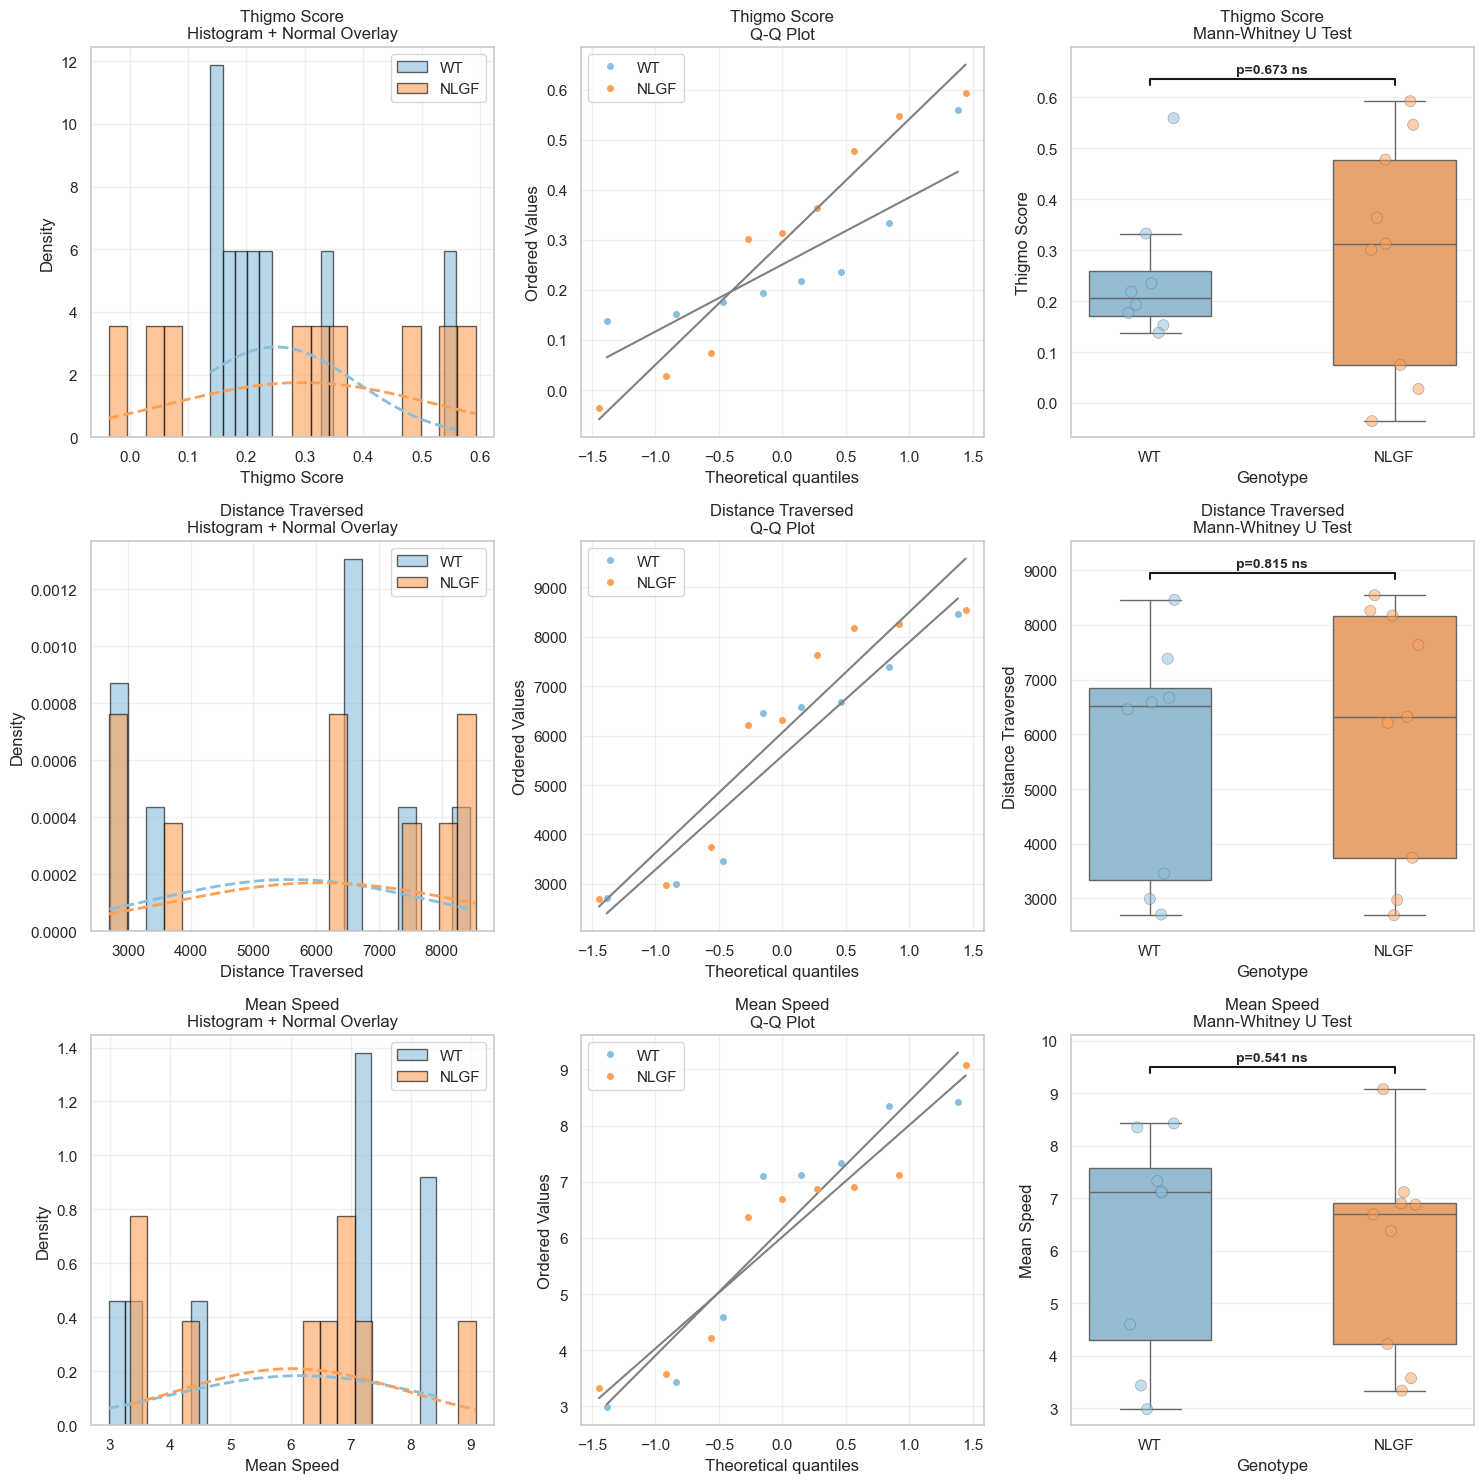



=== NORMALITY TEST RESULTS (Shapiro-Wilk) ===
            metric genotype  n  shapiro_stat  shapiro_p  is_normal
      thigmo_score       WT  8      0.778844   0.016923      False
      thigmo_score     NLGF  9      0.927582   0.458665       True
distance_traversed       WT  8      0.870941   0.153955       True
distance_traversed     NLGF  9      0.860276   0.096550       True
        mean_speed       WT  8      0.857820   0.114206       True
        mean_speed     NLGF  9      0.897692   0.238924       True


=== MANN-WHITNEY U TEST RESULTS (WT vs NLGF) ===
            metric  mann_whitney_U  p_value  significant
      thigmo_score            31.0 0.672974        False
distance_traversed            33.0 0.814809        False
        mean_speed            43.0 0.541423        False


=== INTERPRETATION ===

Normality Tests:
thigmo_score - WT: NOT NORMAL (p=0.0169, n=8)
thigmo_score - NLGF: NORMAL (p=0.4587, n=9)
distance_traversed - WT: NORMAL (p=0.1540, n=8)
distance_traversed - NL

In [38]:
"""
Normality check and distribution plots for thigmo_score, distance_traversed, and mean_speed
by Genotype (WT vs NLGF)
"""

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the input path ONCE (edit this one line only)
open_field_pos = Path("/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/csv_files/open_field_positional_stats.csv")
OPEN_FIELD_DIR = open_field_pos.parent
OPEN_FIELD_Pos_OUTDIR = OPEN_FIELD_DIR.parent / "OpenField_Positional_stats"

OPEN_FIELD_Pos_OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", OPEN_FIELD_Pos_OUTDIR)

df_open_field_pos_stats = pd.read_csv(open_field_pos)

# Columns to check
metrics = ['thigmo_score', 'distance_traversed', 'mean_speed']

"""
Filter for trials ending in 'b.set' from the filename column
"""

# Check if 'filename' column exists
if 'filename' in df_open_field_pos_stats.columns:
    print("Original dataframe shape:", df_open_field_pos_stats.shape)
    print("\nSample filenames before filtering:")
    print(df_open_field_pos_stats['filename'].head(10))
    
    # Filter for filenames ending with 'b.set'
    df_open_field = df_open_field_pos_stats[df_open_field_pos_stats['filename'].str.endswith('b.set', na=False)].copy()
    
    print(f"\nAfter filtering for files ending in 'b.set':")
    print("New dataframe shape:", df_open_field.shape)
    print("\nSample filenames after filtering:")
    print(df_open_field['filename'].head(10))
    
    # Show how many unique filenames remain
    print(f"\nNumber of unique filenames: {df_open_field['filename'].nunique()}")
    
else:
    print("Warning: 'filename' column not found in dataframe")
    print("Available columns:", df_open_field_pos_stats.columns.tolist())

# Check which columns exist in the dataframe
print("Checking for columns in df_open_field...")
available_metrics = [m for m in metrics if m in df_open_field.columns]
missing_metrics = [m for m in metrics if m not in df_open_field.columns]

if missing_metrics:
    print(f"\nWarning: These columns are not in df_open_field: {missing_metrics}")
if available_metrics:
    print(f"\nFound these columns: {available_metrics}")
else:
    print("\nNone of the requested columns found. Available columns:")
    print([c for c in df_open_field.columns if 'thigmo' in c.lower() or 'distance' in c.lower() or 'speed' in c.lower()])

# Proceed with available metrics
if available_metrics:
    # Filter for WT and NLGF genotypes only
    df_analysis = df_open_field[df_open_field['Genotype'].isin(['WT', 'NLGF'])].copy()
    
    # Ensure genotype order is WT, NLGF
    df_analysis['Genotype'] = pd.Categorical(df_analysis['Genotype'], categories=['WT', 'NLGF'], ordered=True)
    
    print(f"\n\nSample sizes:")
    print(df_analysis.groupby('Genotype').size())
    
    # --- Define palette: make WT lighter blue, NLGF lighter orange ---
    hue_order = ['WT', 'NLGF']
    base = sns.color_palette("tab10", n_colors=len(hue_order))
    palette = dict(zip(hue_order, base))
    
    for g in hue_order:
        if "wt" in str(g).strip().lower():
            palette[g] = sns.color_palette("Blues", 6)[2]  # lighter blue
        if "nlgf" in str(g).strip().lower():
            palette[g] = sns.color_palette("Oranges", 6)[2]  # lighter orange
    
    # Create figure for plots
    n_metrics = len(available_metrics)
    fig, axes = plt.subplots(n_metrics, 3, figsize=(15, 5*n_metrics))
    if n_metrics == 1:
        axes = axes.reshape(1, -1)
    
    # Store normality test results
    normality_results = []
    # Store Mann-Whitney test results
    mw_results = []
    
    for i, metric in enumerate(available_metrics):
        # Get data for each genotype
        data_wt = df_analysis[df_analysis['Genotype'] == 'WT'][metric].dropna()
        data_nlgf = df_analysis[df_analysis['Genotype'] == 'NLGF'][metric].dropna()
        
        # Shapiro-Wilk test for normality
        if len(data_wt) >= 3:
            stat_wt, p_wt = stats.shapiro(data_wt)
        else:
            stat_wt, p_wt = np.nan, np.nan
            
        if len(data_nlgf) >= 3:
            stat_nlgf, p_nlgf = stats.shapiro(data_nlgf)
        else:
            stat_nlgf, p_nlgf = np.nan, np.nan
        
        normality_results.append({
            'metric': metric,
            'genotype': 'WT',
            'n': len(data_wt),
            'shapiro_stat': stat_wt,
            'shapiro_p': p_wt,
            'is_normal': p_wt > 0.05 if not np.isnan(p_wt) else None
        })
        
        normality_results.append({
            'metric': metric,
            'genotype': 'NLGF',
            'n': len(data_nlgf),
            'shapiro_stat': stat_nlgf,
            'shapiro_p': p_nlgf,
            'is_normal': p_nlgf > 0.05 if not np.isnan(p_nlgf) else None
        })
        
        # Mann-Whitney U test between genotypes
        if len(data_wt) >= 1 and len(data_nlgf) >= 1:
            mw_stat, mw_p = stats.mannwhitneyu(data_wt, data_nlgf, alternative='two-sided')
            mw_results.append({
                'metric': metric,
                'mann_whitney_U': mw_stat,
                'p_value': mw_p,
                'significant': mw_p < 0.05
            })
        else:
            mw_results.append({
                'metric': metric,
                'mann_whitney_U': np.nan,
                'p_value': np.nan,
                'significant': None
            })
        
        # Pretty metric name
        pretty_metric = metric.replace('_', ' ').title()
        
        # Plot 1: Histogram with normal curve overlay
        ax1 = axes[i, 0]
        for geno in ['WT', 'NLGF']:
            data = df_analysis[df_analysis['Genotype'] == geno][metric].dropna()
            ax1.hist(data, bins=20, alpha=0.6, label=geno, color=palette[geno], density=True, edgecolor='black')
            
            # Overlay normal curve
            if len(data) > 1:
                mu, std = data.mean(), data.std()
                x = np.linspace(data.min(), data.max(), 100)
                ax1.plot(x, stats.norm.pdf(x, mu, std), color=palette[geno], linewidth=2, linestyle='--')
        
        ax1.set_xlabel(pretty_metric)
        ax1.set_ylabel('Density')
        ax1.set_title(f'{pretty_metric}\nHistogram + Normal Overlay')
        ax1.legend()
        ax1.grid(alpha=0.3)
        
        # Plot 2: Q-Q plot
        ax2 = axes[i, 1]
        for geno in ['WT', 'NLGF']:
            data = df_analysis[df_analysis['Genotype'] == geno][metric].dropna()
            if len(data) > 2:
                stats.probplot(data, dist="norm", plot=ax2)
                ax2.get_lines()[-2].set_color(palette[geno])
                ax2.get_lines()[-2].set_marker('o')
                ax2.get_lines()[-2].set_markersize(4)
                ax2.get_lines()[-2].set_label(geno)
                ax2.get_lines()[-1].set_color('gray')
        
        ax2.set_title(f'{pretty_metric}\nQ-Q Plot')
        ax2.legend()
        ax2.grid(alpha=0.3)
        
        # Plot 3: Box plot with Mann-Whitney test annotation
        ax3 = axes[i, 2]
        plot_data = df_analysis[[metric, 'Genotype']].dropna()
        
        # Boxplot with stripplot overlay (thinner boxes)
        sns.boxplot(
            data=plot_data,
            x='Genotype',
            y=metric,
            order=['WT', 'NLGF'],
            palette=palette,
            showfliers=False,
            width=0.5,  # Make boxes thinner
            ax=ax3
        )
        
        # Overlay individual points
        sns.stripplot(
            data=plot_data,
            x='Genotype',
            y=metric,
            order=['WT', 'NLGF'],
            palette=palette,
            alpha=0.5,
            size=8,
            linewidth=0.5,
            color='black',
            ax=ax3
        )
        
        ax3.set_ylabel(pretty_metric)
        ax3.set_xlabel('Genotype')
        ax3.set_title(f'{pretty_metric}\nMann-Whitney U Test')
        ax3.grid(alpha=0.3, axis='y')
        
        # Add Mann-Whitney test result as text annotation
        mw_result = [r for r in mw_results if r['metric'] == metric][0]
        if not np.isnan(mw_result['p_value']):
            p_val = mw_result['p_value']
            if p_val < 0.001:
                p_text = "p<0.001***"
            elif p_val < 0.01:
                p_text = f"p={p_val:.3f}**"
            elif p_val < 0.05:
                p_text = f"p={p_val:.3f}*"
            else:
                p_text = f"p={p_val:.3f} ns"
            
            # Add bracket and p-value annotation
            y_max = plot_data[metric].max()
            y_min = plot_data[metric].min()
            y_range = y_max - y_min
            bracket_height = y_max + 0.05 * y_range
            
            ax3.plot([0, 0, 1, 1], 
                    [bracket_height, bracket_height + 0.02*y_range, 
                     bracket_height + 0.02*y_range, bracket_height], 
                    'k-', linewidth=1.5)
            ax3.text(0.5, bracket_height + 0.03*y_range, p_text, 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
            
            ax3.set_ylim(y_min - 0.05*y_range, bracket_height + 0.12*y_range)
    
    plt.tight_layout()
    plt.savefig(OPEN_FIELD_Pos_OUTDIR / 'normality_check_behavioral_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Display normality test results
    df_normality = pd.DataFrame(normality_results)
    print("\n\n=== NORMALITY TEST RESULTS (Shapiro-Wilk) ===")
    print(df_normality.to_string(index=False))
    
    # Display Mann-Whitney test results
    df_mw = pd.DataFrame(mw_results)
    print("\n\n=== MANN-WHITNEY U TEST RESULTS (WT vs NLGF) ===")
    print(df_mw.to_string(index=False))
    
    # Summary interpretation
    print("\n\n=== INTERPRETATION ===")
    print("\nNormality Tests:")
    for _, row in df_normality.iterrows():
        if pd.notna(row['shapiro_p']):
            result = "NORMAL" if row['is_normal'] else "NOT NORMAL"
            print(f"{row['metric']} - {row['genotype']}: {result} (p={row['shapiro_p']:.4f}, n={row['n']})")
        else:
            print(f"{row['metric']} - {row['genotype']}: Insufficient data (n={row['n']})")
    
    print("\nMann-Whitney U Tests (WT vs NLGF):")
    for _, row in df_mw.iterrows():
        if pd.notna(row['p_value']):
            sig = "SIGNIFICANT" if row['significant'] else "NOT SIGNIFICANT"
            print(f"{row['metric']}: {sig} (U={row['mann_whitney_U']:.2f}, p={row['p_value']:.4f})")
        else:
            print(f"{row['metric']}: Insufficient data")
    
    # Save results to CSV
    df_normality.to_csv(OPEN_FIELD_Pos_OUTDIR / 'normality_test_results.csv', index=False)
    df_mw.to_csv(OPEN_FIELD_Pos_OUTDIR / 'mann_whitney_test_results.csv', index=False)
    print(f"\n\nResults saved to:")
    print(f"  - {OPEN_FIELD_Pos_OUTDIR / 'normality_test_results.csv'}")
    print(f"  - {OPEN_FIELD_Pos_OUTDIR / 'mann_whitney_test_results.csv'}")

else:
    print("\nCannot proceed without any valid column names. Please check your data.")

Using filtered df_open_field_pos_stats with 34 rows (b.set trials only)

Using age column: Age_weeks
Using animal column: mouse_name
Confirmed: 17/34 rows have filenames ending in 'b.set'

Number of animals per genotype:
Genotype
NLGF    9
WT      8
dtype: int64

=== LINEAR REGRESSION STATISTICS (b.set trials only) ===

WT:
  n = 8 animals
  Slope = 318.1032 ± 108.4426
  Intercept = -16328.1221
  R² = 0.5892
  p-value = 2.6172e-02
  Correlation (r) = 0.7676

NLGF:
  n = 9 animals
  Slope = 308.9669 ± 44.9498
  Intercept = -15928.2898
  R² = 0.8710
  p-value = 2.3689e-04
  Correlation (r) = 0.9333


Regression plot saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_Positional_stats/distance_traversed_vs_age_regression_bset.png


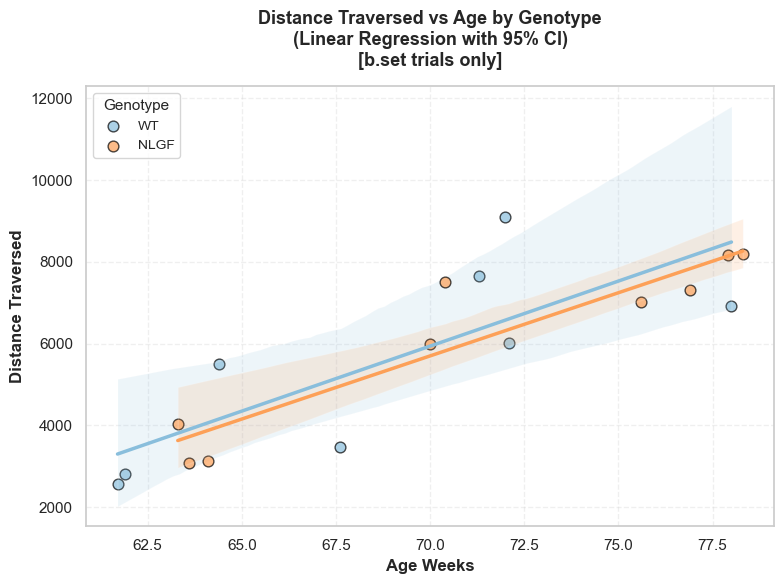

Animal-level data saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_Positional_stats/distance_by_animal_bset.csv


In [39]:
"""
Scatterplot with linear regression: distance_traversed vs age by Genotype
Each point represents an individual animal, with separate regression lines and 95% CI bands for each genotype
Using only trials ending in 'b.set'
"""

# Verify we're using the filtered df_analysis from the cell above
if 'df_open_field_pos_stats' not in locals():
    print("Error: df_open_field_pos_stats not found. Please run the normality check cell first.")
else:
    print(f"Using filtered df_open_field_pos_stats with {len(df_open_field_pos_stats)} rows (b.set trials only)")
    
    # Check if we have the necessary columns
    if 'distance_traversed' in df_open_field_pos_stats.columns:
        # Check for age column (try different possible names)
        age_col = None
        for possible_age_col in ['age', 'Age', 'age_weeks', 'Age_weeks', 'age_days', 'Age_days']:
            if possible_age_col in df_open_field_pos_stats.columns:
                age_col = possible_age_col
                break
        
        if age_col is None:
            print("Warning: No age column found in dataframe")
            print("Available columns:", df_open_field_pos_stats.columns.tolist())
        else:
            print(f"\nUsing age column: {age_col}")
            
            # Check for animal identifier column
            animal_col = None
            for possible_animal_col in ['mouse_name', 'Mouse_name', 'subject_id', 'Subject_id', 'animal_id', 'Animal_id']:
                if possible_animal_col in df_open_field_pos_stats.columns:
                    animal_col = possible_animal_col
                    break
            
            if animal_col is None:
                print("Warning: No animal identifier column found")
                print("Available columns:", df_open_field_pos_stats.columns.tolist())
            else:
                print(f"Using animal column: {animal_col}")
                
                # Verify we have filename info to confirm filtering
                if 'filename' in df_open_field_pos_stats.columns:
                    n_bset = df_open_field_pos_stats['filename'].str.endswith('b.set', na=False).sum()
                    print(f"Confirmed: {n_bset}/{len(df_open_field_pos_stats)} rows have filenames ending in 'b.set'")
                
                # Aggregate by animal to get one point per animal
                df_by_animal = df_open_field_pos_stats.groupby([animal_col, 'Genotype'], as_index=False).agg({
                    'distance_traversed': 'mean',
                    age_col: 'first'  # assuming age is constant per animal
                }).dropna()
                
                print(f"\nNumber of animals per genotype:")
                print(df_by_animal.groupby('Genotype').size())
                
                # Create the regression plot
                fig, ax = plt.subplots(figsize=(8, 6))
                
                # Plot with seaborn regplot for each genotype
                for geno in ['WT', 'NLGF']:
                    data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                    
                    if len(data_geno) >= 2:
                        # Regression plot with 95% CI
                        sns.regplot(
                            data=data_geno,
                            x=age_col,
                            y='distance_traversed',
                            color=palette[geno],
                            scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolors': 'black', 'linewidths': 1},
                            line_kws={'linewidth': 2.5},
                            label=geno,
                            ax=ax
                        )
                
                # Formatting
                ax.set_xlabel(age_col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
                ax.set_ylabel('Distance Traversed', fontsize=12, fontweight='bold')
                ax.set_title('Distance Traversed vs Age by Genotype\n(Linear Regression with 95% CI)\n[b.set trials only]', 
                            fontsize=13, fontweight='bold', pad=15)
                ax.legend(title='Genotype', fontsize=10, title_fontsize=11)
                ax.grid(alpha=0.3, linestyle='--')
                
                # Compute and display regression statistics for each genotype
                from scipy import stats as scipy_stats
                
                print("\n=== LINEAR REGRESSION STATISTICS (b.set trials only) ===")
                for geno in ['WT', 'NLGF']:
                    data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                    
                    if len(data_geno) >= 2:
                        x = data_geno[age_col].values
                        y = data_geno['distance_traversed'].values
                        
                        # Remove any NaN values
                        mask = ~(np.isnan(x) | np.isnan(y))
                        x = x[mask]
                        y = y[mask]
                        
                        if len(x) >= 2:
                            slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(x, y)
                            
                            print(f"\n{geno}:")
                            print(f"  n = {len(x)} animals")
                            print(f"  Slope = {slope:.4f} ± {std_err:.4f}")
                            print(f"  Intercept = {intercept:.4f}")
                            print(f"  R² = {r_value**2:.4f}")
                            print(f"  p-value = {p_value:.4e}")
                            print(f"  Correlation (r) = {r_value:.4f}")
                
                plt.tight_layout()
                
                # Save figure to OPEN_FIELD_Pos_OUTDIR (same as normality check cell)
                regression_fig_path = OPEN_FIELD_Pos_OUTDIR / 'distance_traversed_vs_age_regression_bset.png'
                plt.savefig(regression_fig_path, dpi=300, bbox_inches='tight')
                print(f"\n\nRegression plot saved to: {regression_fig_path}")
                
                plt.show()
                
                # Save the aggregated data to CSV (same directory as normality results)
                df_by_animal.to_csv(OPEN_FIELD_Pos_OUTDIR / 'distance_by_animal_bset.csv', index=False)
                print(f"Animal-level data saved to: {OPEN_FIELD_Pos_OUTDIR / 'distance_by_animal_bset.csv'}")
    else:
        print("Warning: 'distance_traversed' column not found in df_analysis")

Using filtered df_analysis with 17 rows (b.set trials only)
Using age column: Age_weeks
Using animal column: mouse_name

Debug info:
  Unique animals: 17
  Unique genotypes: 2
  Total rows: 17

Number of animals per genotype:
Genotype
NLGF    9
WT      8
dtype: int64

=== LINEAR REGRESSION STATISTICS (b.set trials only) ===

WT:
  n = 8 animals
  Slope = -0.0082 ± 0.0093
  Intercept = 0.8167
  R² = 0.1167
  p-value = 4.0750e-01
  Correlation (r) = -0.3417

NLGF:
  n = 9 animals
  Slope = 0.0198 ± 0.0115
  Intercept = -1.1147
  R² = 0.2996
  p-value = 1.2718e-01
  Correlation (r) = 0.5473


Regression plot saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_Positional_stats/thigmo_score_vs_age_regression_bset.png


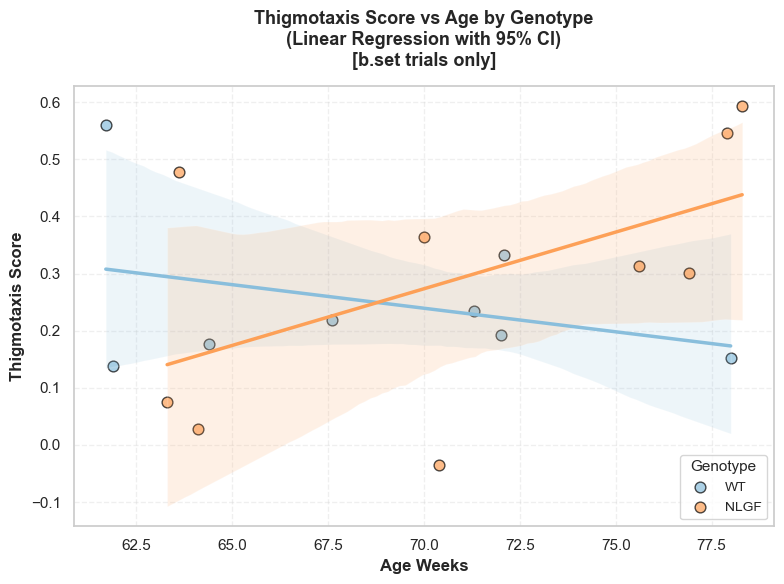

Animal-level data saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_Positional_stats/thigmo_by_animal_bset.csv


In [50]:
"""
Scatterplot with linear regression: thigmotaxis score vs age by Genotype
Each point represents an individual animal, with separate regression lines and 95% CI bands for each genotype
Using only trials ending in 'b.set'
"""

# Reload the data fresh to ensure clean state
open_field_pos = Path("/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/csv_files/open_field_positional_stats.csv")
OPEN_FIELD_Pos_OUTDIR = open_field_pos.parent.parent / "OpenField_Positional_stats"
OPEN_FIELD_Pos_OUTDIR.mkdir(parents=True, exist_ok=True)

# Load fresh data
df_full = pd.read_csv(open_field_pos)

# Filter for b.set trials
df_analysis = df_full[df_full['filename'].str.endswith('b.set', na=False)].copy()

# Filter for WT and NLGF only
df_analysis = df_analysis[df_analysis['Genotype'].isin(['WT', 'NLGF'])].copy()

print(f"Using filtered df_analysis with {len(df_analysis)} rows (b.set trials only)")

# Check if we have the necessary columns
if 'thigmo_score' in df_analysis.columns:
    # Check for age column
    age_col = None
    for possible_age_col in ['age', 'Age', 'age_weeks', 'Age_weeks', 'age_days', 'Age_days']:
        if possible_age_col in df_analysis.columns:
            age_col = possible_age_col
            break
    
    if age_col is None:
        print("Warning: No age column found in dataframe")
        print("Available columns:", df_analysis.columns.tolist())
    else:
        print(f"Using age column: {age_col}")
        
        # Check for animal identifier column
        animal_col = None
        for possible_animal_col in ['mouse_name', 'Mouse_name', 'subject_id', 'Subject_id', 'animal_id', 'Animal_id']:
            if possible_animal_col in df_analysis.columns:
                animal_col = possible_animal_col
                break
        
        if animal_col is None:
            print("Warning: No animal identifier column found")
            print("Available columns:", df_analysis.columns.tolist())
        else:
            print(f"Using animal column: {animal_col}")
            
            # Debug: Check what we're grouping by
            print(f"\nDebug info:")
            print(f"  Unique animals: {df_analysis[animal_col].nunique()}")
            print(f"  Unique genotypes: {df_analysis['Genotype'].nunique()}")
            print(f"  Total rows: {len(df_analysis)}")
            
            # Aggregate by animal to get one point per animal
            df_by_animal = (df_analysis
                           .groupby([animal_col, 'Genotype'], as_index=False)
                           .agg({
                               'thigmo_score': 'mean',
                               age_col: 'first'
                           })
                           .dropna())
            
            print(f"\nNumber of animals per genotype:")
            print(df_by_animal.groupby('Genotype').size())
            
            # Define palette (using same as normality cell)
            hue_order = ['WT', 'NLGF']
            base = sns.color_palette("tab10", n_colors=len(hue_order))
            palette = dict(zip(hue_order, base))
            for g in hue_order:
                if "wt" in str(g).strip().lower():
                    palette[g] = sns.color_palette("Blues", 6)[2]
                if "nlgf" in str(g).strip().lower():
                    palette[g] = sns.color_palette("Oranges", 6)[2]
            
            # Create the regression plot
            fig, ax = plt.subplots(figsize=(8, 6))
            
            # Plot with seaborn regplot for each genotype
            for geno in ['WT', 'NLGF']:
                data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                
                if len(data_geno) >= 2:
                    # Regression plot with 95% CI
                    sns.regplot(
                        data=data_geno,
                        x=age_col,
                        y='thigmo_score',
                        color=palette[geno],
                        scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolors': 'black', 'linewidths': 1},
                        line_kws={'linewidth': 2.5},
                        label=geno,
                        ax=ax
                    )
            
            # Formatting
            ax.set_xlabel(age_col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
            ax.set_ylabel('Thigmotaxis Score', fontsize=12, fontweight='bold')
            ax.set_title('Thigmotaxis Score vs Age by Genotype\n(Linear Regression with 95% CI)\n[b.set trials only]', 
                        fontsize=13, fontweight='bold', pad=15)
            ax.legend(title='Genotype', fontsize=10, title_fontsize=11)
            ax.grid(alpha=0.3, linestyle='--')
            
            # Compute and display regression statistics for each genotype
            from scipy import stats as scipy_stats
            
            print("\n=== LINEAR REGRESSION STATISTICS (b.set trials only) ===")
            for geno in ['WT', 'NLGF']:
                data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                
                if len(data_geno) >= 2:
                    x = data_geno[age_col].values
                    y = data_geno['thigmo_score'].values
                    
                    # Remove any NaN values
                    mask = ~(np.isnan(x) | np.isnan(y))
                    x = x[mask]
                    y = y[mask]
                    
                    if len(x) >= 2:
                        slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(x, y)
                        
                        print(f"\n{geno}:")
                        print(f"  n = {len(x)} animals")
                        print(f"  Slope = {slope:.4f} ± {std_err:.4f}")
                        print(f"  Intercept = {intercept:.4f}")
                        print(f"  R² = {r_value**2:.4f}")
                        print(f"  p-value = {p_value:.4e}")
                        print(f"  Correlation (r) = {r_value:.4f}")
            
            plt.tight_layout()
            
            # Save figure
            regression_fig_path = OPEN_FIELD_Pos_OUTDIR / 'thigmo_score_vs_age_regression_bset.png'
            plt.savefig(regression_fig_path, dpi=300, bbox_inches='tight')
            print(f"\n\nRegression plot saved to: {regression_fig_path}")
            
            plt.show()
            
            # Save the aggregated data to CSV
            df_by_animal.to_csv(OPEN_FIELD_Pos_OUTDIR / 'thigmo_by_animal_bset.csv', index=False)
            print(f"Animal-level data saved to: {OPEN_FIELD_Pos_OUTDIR / 'thigmo_by_animal_bset.csv'}")
else:
    print("Warning: 'thigmo_score' column not found in df_analysis")

In [51]:
"""
Calculate for each mouse the % of cells that are nan for field_size out of all cells recorded for that mouse, and save to a new dataframe with columns: mouse_name, Genotype, Cell type, percent_nan_field_size
"""
# Check if necessary columns exist
required_cols = ['mouse_name', 'Genotype', 'Cell type', 'field_size']
missing_cols = [col for col in required_cols if col not in df_open_field.columns]
if missing_cols:
    print(f"Warning: Missing columns in dataframe: {missing_cols}")
    print("Available columns:", df_open_field.columns.tolist())
else:
    # Calculate percent of cells that are NaN for field_size per mouse
    df_nan_summary = (df_open_field
                      .groupby(['mouse_name', 'Genotype', 'Cell type'])
                      .agg(
                          total_cells=('field_size', 'size'),
                          nan_cells=('field_size', lambda x: x.isna().sum())
                      )
                      .reset_index())
    
    df_nan_summary['percent_nan_field_size'] = (df_nan_summary['nan_cells'] / df_nan_summary['total_cells']) * 100
    
    # Select relevant columns
    df_nan_summary = df_nan_summary[['mouse_name', 'Genotype', 'Cell type', 'percent_nan_field_size']]
    
    print(df_nan_summary.head())
    
    # Save to CSV
    nan_summary_path = Path("/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis") / 'percent_nan_field_size_by_mouse.csv'
    df_nan_summary.to_csv(nan_summary_path, index=False)
    print(f"\nPercent NaN summary saved to: {nan_summary_path}")   

   mouse_name Genotype    Cell type  percent_nan_field_size
0      644788     NLGF  Interneuron               90.000000
1      644788     NLGF    Pyramidal               39.130435
2      667893       WT  Interneuron               50.000000
3      667893       WT    Pyramidal               26.315789
4      708153     NLGF  Interneuron              100.000000

Percent NaN summary saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/percent_nan_field_size_by_mouse.csv
